## Reaction to economic shocks: 
How did trade and unemployment react to the 2009 and 2020 crises, and which countries recovered fastest?

In [ ]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean

sns.set_theme(style= "whitegrid")

conn = sqlite3.connect(Path.cwd().parent/"database/ue_market.db")
pd.read_sql("SELECT name FROM sqlite_master WHERE   type= 'table'", conn)

,name
0,trade_category
1,trade_total
2,unemployment_ue
3,data_breaks_ue
4,gdp_ue


In [ ]:
import_export_countries= pd.read_sql("""
WITH CTE_country_name AS(
	SELECT DISTINCT
		country_code,
		country
	FROM
		gdp_ue)

SELECT 
	a.country_code,
	b.country,
	a.year,
	MAX(CASE WHEN indic_et= 'export' THEN value_meur END) AS export,
	MAX(CASE WHEN indic_et= 'import' THEN value_meur END) AS import
FROM
	trade_total a
JOIN CTE_country_name b ON a.country_code = b.country_code
WHERE
	indic_et IN ('export','import')
GROUP BY a.country_code, b.country, a.year
ORDER BY a.country_code, year""",
conn)

In [ ]:
import_export_countries.head(5)

,country_code,country,year,export,import
0,AT,Austria,2002,83199.0,82803.6
1,AT,Austria,2003,85878.8,87987.5
2,AT,Austria,2004,95164.9,96394.7
3,AT,Austria,2005,100620.6,102344.8
4,AT,Austria,2006,108913.1,109280.0


I chose to use Pandas functions rather than SQL for this type of analysis, as I needed to frequently switch between imports and exports and analyze different time periods.

### Export analysis for 2008 crisis.

Initially, I will analyze how exports changed before and after the 2008 crisis. I will only use the trade_total database, since the unemployment_ue and gdp_ue databases only start from 2016. <br>I will begin by building the analysis on a single country, and then I will create a function to include all of them.

In [ ]:
import_export_Austria= import_export_countries[import_export_countries['country_code'] == 'AT']

In [ ]:
max_export_precrisis= import_export_Austria[import_export_Austria['year'].isin([2006, 2007, 2008])]['export'].max()

In [ ]:
min_export_post_crisis= import_export_Austria[import_export_Austria['year'].isin([2009,2010,2011])]['export'].min()

In [ ]:
((min_export_post_crisis - max_export_precrisis) / max_export_precrisis * 100).round(2)

np.float64(-20.32)

In [ ]:
recovery = import_export_Austria[(import_export_Austria['year'] >= 2009) & 
    (import_export_Austria['export'] >= max_export_precrisis)]['year'].min()

In [ ]:
recovery

np.int64(2011)

Now, I will create a parametric function to analyze each country during specific year ranges, so that it can also be reused for the 2020 crisis.

In [ ]:
def analyze_export_shock(country_code, years_precrisis, years_post_crisis, first_year_post_crisis, export_col='export'):
    country_data = import_export_countries[import_export_countries['country_code'] == country_code]
    
    max_precrisis = country_data[country_data['year'].isin(years_precrisis)][export_col].max()
    min_post_crisis = country_data[country_data['year'].isin(years_post_crisis)][export_col].min()
    
    shock_percentage = ((min_post_crisis - max_precrisis) / max_precrisis * 100).round(2)
    
    recovery_year = country_data[
        (country_data['year'] >= first_year_post_crisis) & 
        (country_data[export_col] >= max_precrisis)
    ]['year'].min()

    country_name = country_data['country'].iloc[0]
    
    return pd.DataFrame({
        "country_code": [country_code],
        "country" : [country_name],
        f"max_{export_col}_precrisis": [max_precrisis],
        f"min_{export_col}_post_crisis": [min_post_crisis],
        "shock_percentage": [shock_percentage],
        "recovery_year": [recovery_year]
    })

In [ ]:
#apply the function to all countries and concatenate the results into a single dataframe

years_precrisis = [2006, 2007, 2008]
years_post_crisis = [2009, 2010, 2011]

export_results_2008 = pd.concat([analyze_export_shock(code, years_precrisis, years_post_crisis, 2009, export_col='export') 
                     for code in import_export_countries['country_code'].unique()], ignore_index= True)

In [ ]:
export_results_2008

,country_code,country,max_export_precrisis,min_export_post_crisis,shock_percentage,recovery_year
0,AT,Austria,123258.8,98213.7,-20.32,2011.0
1,BE,Belgium,320805.2,265986.0,-17.09,2011.0
2,BG,Bulgaria,15204.1,11699.5,-23.05,2010.0
3,CY,Cyprus,1110.3,901.5,-18.81,2011.0
4,CZ,Czechia,99809.1,80983.3,-18.86,2010.0
5,DE,Germany,983255.0,803011.6,-18.33,2011.0
6,DK,Denmark,79495.9,67381.7,-15.24,2011.0
7,EE,Estonia,8470.1,6486.9,-23.41,2010.0
8,EL,Greece,21227.7,18015.1,-15.13,2011.0
9,ES,Spain,191387.8,162990.0,-14.84,2010.0


In [ ]:
export_results_2008[export_results_2008['shock_percentage'] == export_results_2008['shock_percentage'].min()]

,country_code,country,max_export_precrisis,min_export_post_crisis,shock_percentage,recovery_year
10,FI,Finland,65687.6,45063.4,-31.4,2021.0


In [ ]:
export_results_2008[export_results_2008['shock_percentage'] == export_results_2008['shock_percentage'].max()]

,country_code,country,max_export_precrisis,min_export_post_crisis,shock_percentage,recovery_year
14,IE,Ireland,88685.5,83114.4,-6.28,2011.0


In [ ]:
trim_mean(export_results_2008['shock_percentage'], proportiontocut=0.05).round(2)

np.float64(-19.11)

The country hardest hit in terms of exports during the 2008 crisis was Finland (-31.40%), while the least affected was Ireland (-6.28%). No country was immune to the 2008 crisis, with an average export shock percentage of -19.11%. A special case is Luxembourg, which never recovered its pre-crisis export levels (resulting in a NaN recovery year) due to its structural shift toward digital and financial services that are not captured in merchandise trade data. 

In [ ]:
def plot_economic_shock(df, trade_type="Export", crisis_year="2008"):
    plt.figure(figsize=(15, 6))
    
    df_sorted = df.sort_values(by='shock_percentage', ascending=True)
    
    sns.barplot(data=df_sorted, x='country', y='shock_percentage', hue='country', palette='Set2', legend=False)
    plt.title(f'Percentage Drop in {trade_type} Value from Pre-crisis Peak to Post-crisis Minimum ({crisis_year} Crisis)', fontsize=14, pad=15)
    plt.xlabel('Country', fontsize=11)
    plt.ylabel(f'Economic Shock Intensity (%)', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.grid(True, linestyle="--", alpha=0.5, axis='y')
    plt.tight_layout()

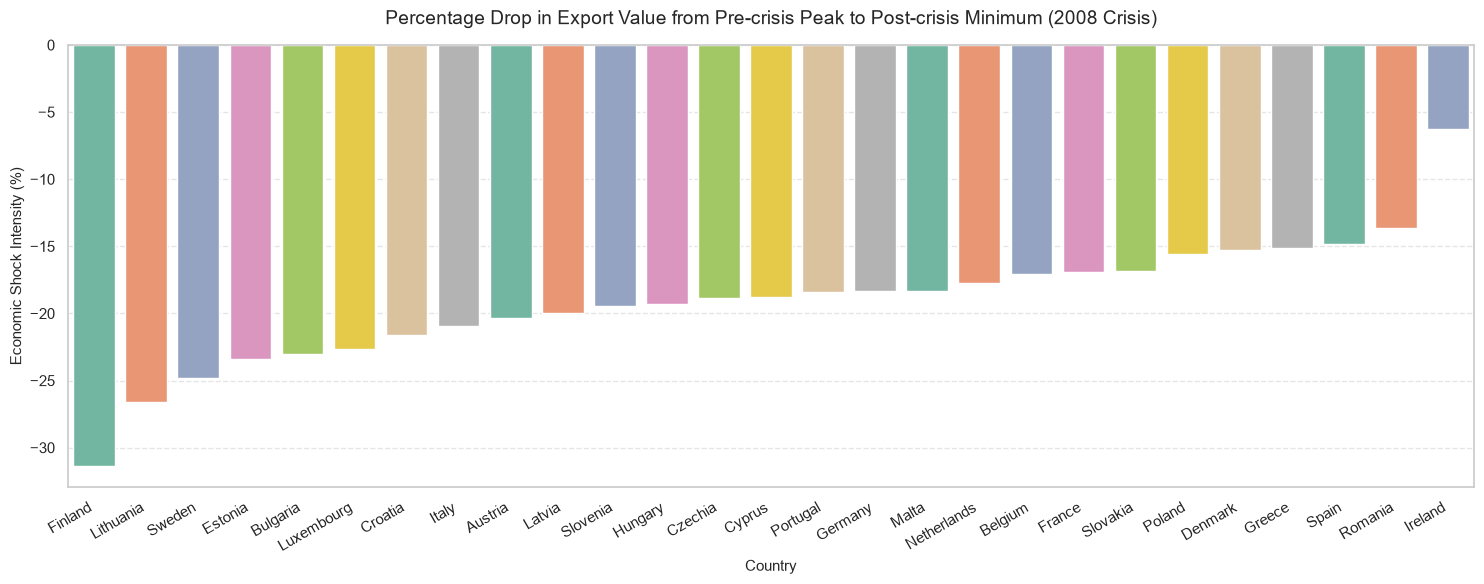

In [ ]:
plot_economic_shock(export_results_2008, trade_type="Export", crisis_year="2008")
plt.savefig(Path.cwd().parent/"data/charts/precrisis_postcrisis_export_2008.png", dpi=150, bbox_inches="tight")
plt.show()

From this graph, we can clearly observe the relative intensity of the economic shock across European countries, measured by the percentage drop in exports from their pre-crisis peak to their post-crisis minimum. 

The data reveals that the Baltic states were the hardest hit in all of Europe, with Lithuania, Latvia, and Estonia experiencing a dramatic collapse of over 35%. 

A special case is Finland. While it was not the absolute hardest hit (ranking 6th with a contraction of -31.40%), it represents a major structural anomaly. Unlike the Baltic countries or the core industrial economies which recovered quickly, Finland’s economic model — heavily centered on advanced services, public administration, and a restructuring technology sector — faced a prolonged stagnation. Consequently, Finland was unable to return to its pre-2008 peak until 2021, a recovery delayed further by the 2020 pandemic.

Conversely, major core economies like Germany, France, and Italy proved to be more resilient to the initial shock, suffering smaller relative drops (around -17% to -20%) and achieving a synchronized recovery by 2011. Malta stands out as the most resilient nation in the dataset, containing its export drop to just over 10%.

### Import analysis for 2008 crisis.

I will now proceed with the analysis of imports during the 2008 crisis, following the same approach used for the export analysis.

In [ ]:
years_precrisis = [2006, 2007, 2008]
years_post_crisis = [2009, 2010, 2011]

import_results_2008 = pd.concat([analyze_export_shock(code, years_precrisis, years_post_crisis, 2009, export_col='import') 
                     for code in import_export_countries['country_code'].unique()], ignore_index= True)

In [ ]:
import_results_2008

,country_code,country,max_import_precrisis,min_import_post_crisis,shock_percentage,recovery_year
0,AT,Austria,125301.4,102569.1,-18.14,2011
1,BE,Belgium,317043.4,254367.4,-19.77,2011
2,BG,Bulgaria,25093.9,16875.9,-32.75,2012
3,CY,Cyprus,7236.6,5617.3,-22.38,2017
4,CZ,Czechia,96571.9,75314.0,-22.01,2011
5,DE,Germany,805729.5,664143.3,-17.57,2011
6,DK,Denmark,74355.6,59602.1,-19.84,2014
7,EE,Estonia,11439.1,7269.9,-36.45,2011
8,EL,Greece,65529.4,47888.2,-26.92,2022
9,ES,Spain,286104.9,210222.0,-26.52,2017


In [ ]:
import_results_2008[import_results_2008['shock_percentage'] == import_results_2008['shock_percentage'].min()]

,country_code,country,max_import_precrisis,min_import_post_crisis,shock_percentage,recovery_year
16,LT,Lithuania,21144.1,13123.0,-37.94,2011


In [ ]:
import_results_2008[import_results_2008['shock_percentage'] == import_results_2008['shock_percentage'].max()]

,country_code,country,max_import_precrisis,min_import_post_crisis,shock_percentage,recovery_year
19,MT,Malta,3603.6,3210.2,-10.92,2010


In [ ]:
trim_mean(import_results_2008['shock_percentage'], proportiontocut=0.05).round(2)

np.float64(-24.4)

The country hardest hit in terms of imports during the 2008 crisis was Lithuania (-37.94%), closely followed by Latvia and Estonia, while the least affected was Malta (-10.92%). No country was immune to the 2008 crisis, with an average import shock percentage of -24.4%. Unlike the export analysis, Luxembourg did recover its pre-crisis import levels, but only in 2021. Meanwhile, Greece represents a major outlier, taking 14 years (until 2022) to recover its import volumes due to the severe domestic austerity and debt crisis that followed 2008.

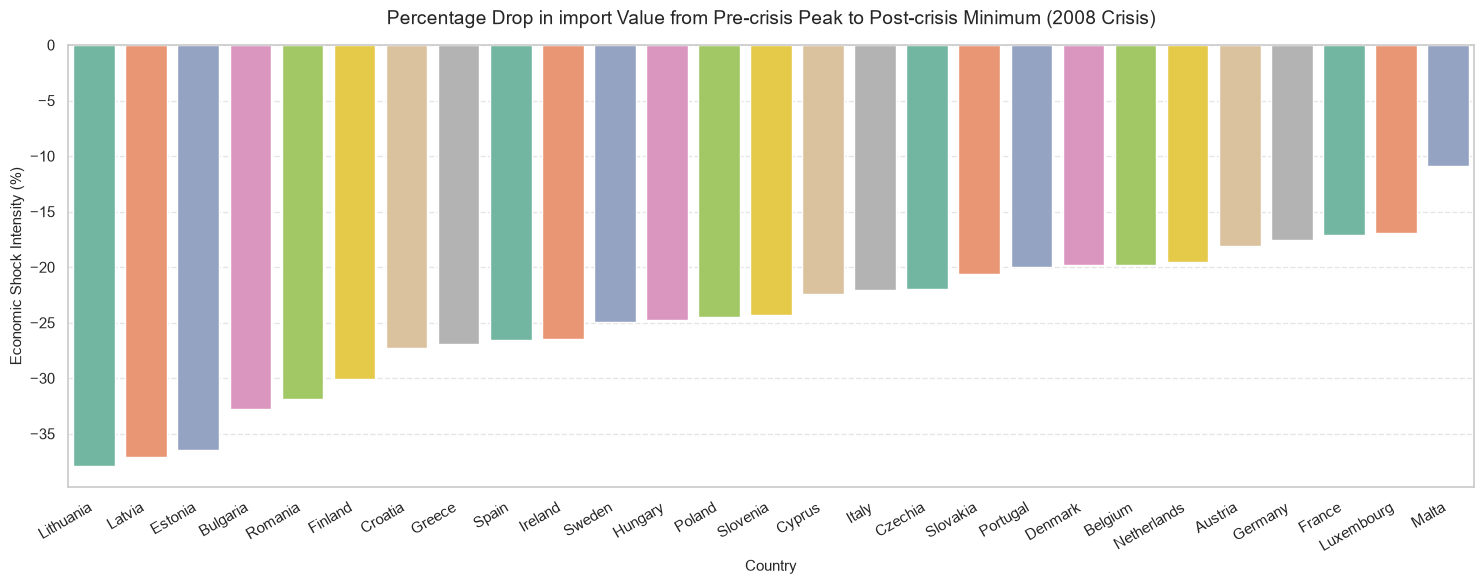

In [ ]:
plot_economic_shock(import_results_2008, trade_type="import", crisis_year="2008")
plt.savefig(Path.cwd().parent/"data/charts/precrisis_postcrisis_import_2008.png", dpi=150, bbox_inches="tight")
plt.show()

From this graph, we can observe the relative intensity of the economic shock on domestic demand across European countries, measured by the percentage drop in imports from their pre-crisis peak to their post-crisis minimum.

The visual distribution confirms that the Baltic states were the hardest hit in terms of imports as well, with Lithuania, Latvia, and Estonia suffering a massive contraction of over 35%. This indicates a severe and immediate collapse in domestic consumption and investment within these economies during the initial phase of the crisis.

Greece and Spain also appear on the left side of the chart, showing high vulnerability with import drops around -26%. For Greece, this initial shock marked the beginning of a historic, long-term austerity period, as highlighted by its 14-year recovery timeline.

On the other hand, major core economies such as Germany and France demonstrated stronger structural resilience, keeping their import contractions under -18%. Malta stands out once again as the most stable country in the dataset, restricting its import drop to just over -10%, which reflects a highly resilient domestic market compared to the rest of the European Union.

### Conclusions for the 2008 Crisis

In conclusion, the 2008 crisis highlighted a profound structural dichotomy across European economies, reshaping their trade patterns for over a decade. Statistically, the shock was asymmetric: while the average European export contraction was severe (-19.11%), the collapse in imports was significantly worse (-24.40%). This clear divergence proves that the 2008 crisis acted primarily as a domestic demand shock within the EU, destroying internal consumption and investment much more than global trade channels.

Chronologically, the recovery speeds split Europe into two distinct tiers:
- **The Resilient Core**: Major industrial exporters like Germany, France, and Italy, along with tightly integrated supply chains like Czechia and Slovakia, achieved a synchronized recovery by 2010–2011, proving the strength of complex manufacturing economies.
- **The Structural Outliers**: Countries like Finland, Greece, and Luxembourg faced unique, long-term challenges. Finland’s heavy industrial drop and structural shift toward domestic services delayed its export recovery until 2021. Luxembourg's data captured a permanent transition toward digital and financial services, leaving its merchandise exports unrecovered (NaN). Finally, Greece represented the most dramatic case, where a deep sovereign debt crisis suppressed domestic purchasing power, delaying its import recovery for 14 years (until 2022).

Ultimately, this analysis demonstrates that a country's resistance to global economic shocks does not depend on trade volume alone, but on the qualitative nature of its economic model and its domestic financial stability.

### Export analysis for 2020 crisis.

I will now proceed with the analysis of exports during the 2020 crisis, following the same approach used for the previous analysis.<br>First of all, I will use the function created previously to analyze the export shock during the 2020 crisis.

In [ ]:
years_precrisis_2020 = [2017, 2018, 2019]
years_post_crisis_2020 = [2020, 2021]
export_results_2020 = pd.concat([analyze_export_shock(code, years_precrisis_2020, years_post_crisis_2020, 2020, export_col='export') 
                          for code in import_export_countries['country_code'].unique()], ignore_index=True)

In [ ]:
export_results_2020

,country_code,country,max_export_precrisis,min_export_post_crisis,shock_percentage,recovery_year
0,AT,Austria,159588.5,148288.0,-7.08,2021
1,BE,Belgium,399841.1,369963.6,-7.47,2021
2,BG,Bulgaria,29788.7,27966.9,-6.12,2021
3,CY,Cyprus,4251.7,2696.9,-36.57,2022
4,CZ,Czechia,177903.0,167597.4,-5.79,2021
5,DE,Germany,1330414.0,1209207.7,-9.11,2021
6,DK,Denmark,99237.2,95027.5,-4.24,2021
7,EE,Estonia,14422.4,14273.8,-1.03,2021
8,EL,Greece,33864.5,30800.7,-9.05,2021
9,ES,Spain,298337.0,269521.0,-9.66,2021


In [ ]:
export_results_2020[export_results_2020['shock_percentage'] == export_results_2020['shock_percentage'].max()]

,country_code,country,max_export_precrisis,min_export_post_crisis,shock_percentage,recovery_year
14,IE,Ireland,151515.6,157828.3,4.17,2020


In [ ]:
export_results_2020[export_results_2020['shock_percentage'] == export_results_2020['shock_percentage'].min()]

,country_code,country,max_export_precrisis,min_export_post_crisis,shock_percentage,recovery_year
3,CY,Cyprus,4251.7,2696.9,-36.57,2022


In [ ]:
trim_mean(export_results_2020['shock_percentage'], proportiontocut=0.05).round(2)

np.float64(-6.98)

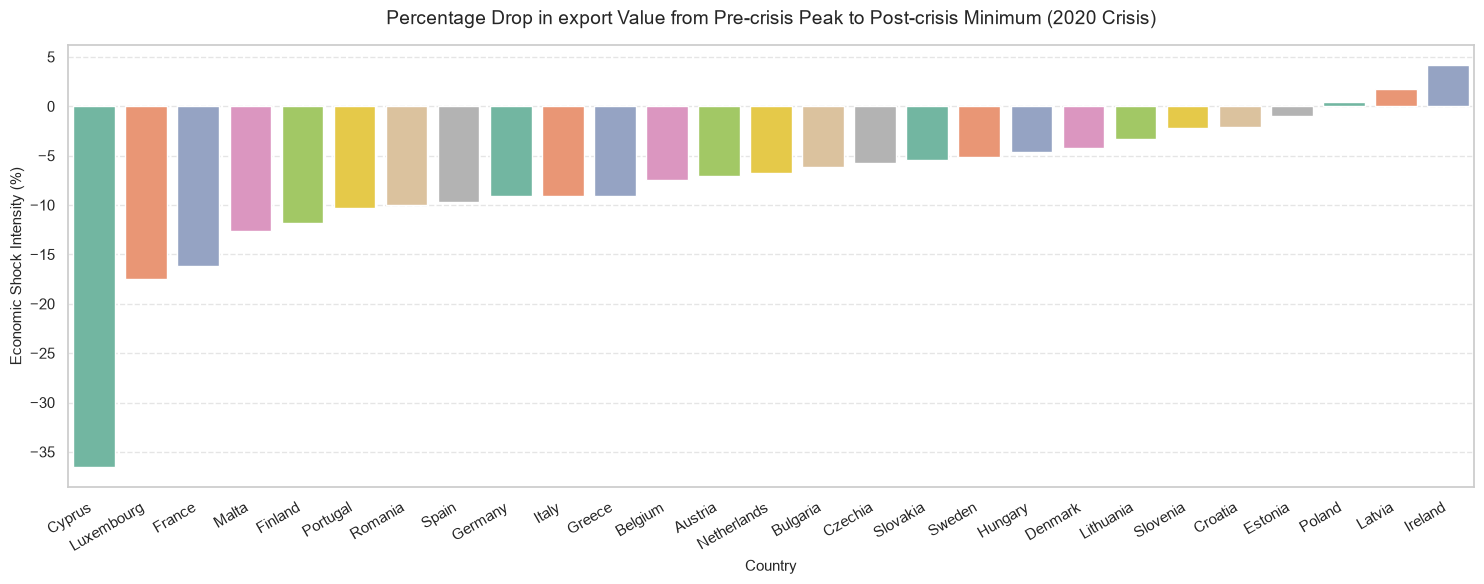

In [ ]:
plot_economic_shock(export_results_2020, trade_type="export", crisis_year="2020")
plt.savefig(Path.cwd().parent/"data/charts/precrisis_postcrisis_export_2020.png", dpi=150, bbox_inches="tight")
plt.show()

Based on an initial analysis, the 2020 crisis had a much lower impact on exports compared to the 2008 financial crisis.There are wide extremes; for instance, Cyprus, which was close to the average percentage shock during the first crisis, was the hardest hit in 2020 with a drop of 36.57%. Conversely, Ireland even saw an increase in exports during the 2020 crisis, recording a 4.17% export bonus.The average shock—calculated using the trimmed mean to eliminate these extreme values—settles at -6.98%, which is significantly lower than in 2008.Furthermore, almost all countries recovered their export levels by 2021, with only a few exceptions (Luxembourg, France, Cyprus, and Malta) bouncing back in 2022.

I am creating a chart to visually demonstrate how significant the difference in exports is between the 2008 crisis and the 2020 crisis.

In [ ]:
def plot_comparison_shock(df_2008, df_2020, trade_type="Export"):

    data = {
        "country": df_2008["country"].tolist(),
        "shock_2008_percentage": df_2008["shock_percentage"].tolist(),
        "shock_2020_percentage": df_2020["shock_percentage"].tolist()
    }

    df_plot = pd.DataFrame(data)

    df_long = pd.melt(df_plot, id_vars=["country"], value_vars=["shock_2008_percentage", "shock_2020_percentage"],
                    var_name="crisis_year", value_name="shock_percentage")

    plt.figure(figsize=(12, 7))
    sns.barplot(data=df_long, x='country', y='shock_percentage', hue='crisis_year', palette='Set2')
    plt.title(f'{trade_type} Shocks from 2008 and 2020 Crises')
    plt.xlabel('Country')
    plt.ylabel('Average Shock Intensity (%)')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Crisis Year', loc='lower right')
    plt.tight_layout()

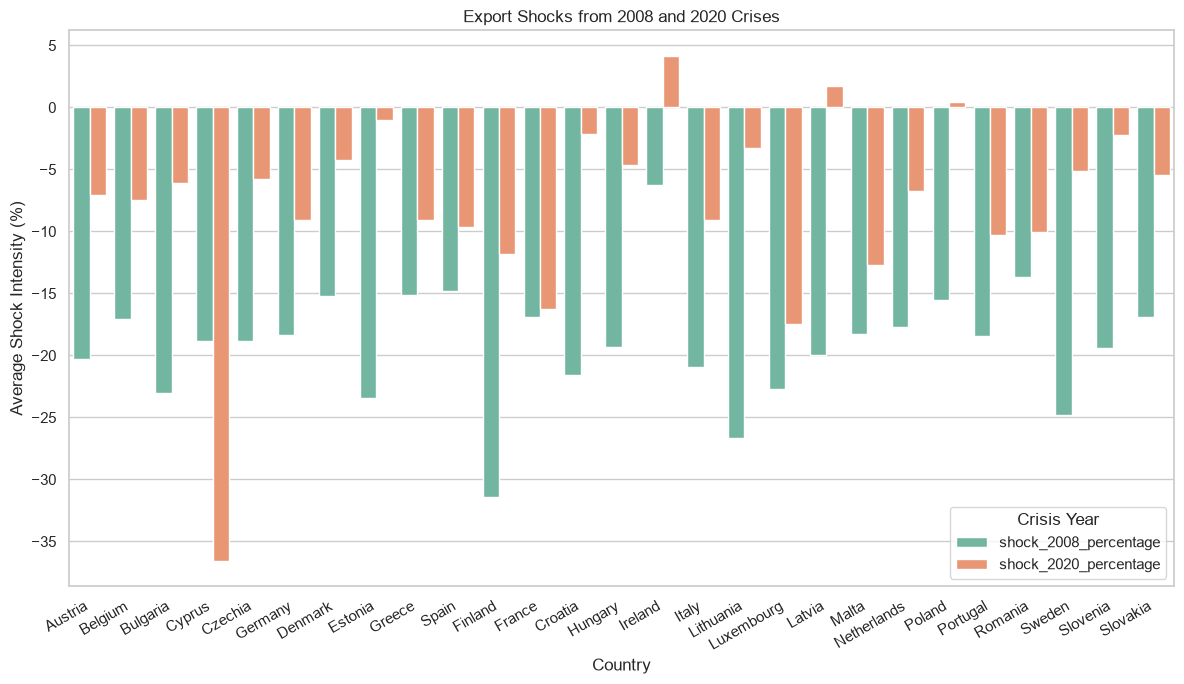

In [ ]:
plot_comparison_shock(export_results_2008, export_results_2020, trade_type="Export")
plt.savefig(Path.cwd().parent/"data/charts/comparison_export_2008_2020.png", dpi=150, bbox_inches="tight")
plt.show()

### Import analysis for 2020 crisis.

I will now proceed with the analysis of imports during the 2020 crisis, following the same approach used for the export analysis.

In [ ]:
years_precrisis_2020 = [2017, 2018, 2019]
years_post_crisis_2020 = [2020, 2021]
import_results_2020 = pd.concat([analyze_export_shock(code, years_precrisis_2020, years_post_crisis_2020, 2020, export_col='import') 
                          for code in import_export_countries['country_code'].unique()], ignore_index=True)

In [ ]:
import_results_2020

,country_code,country,max_import_precrisis,min_import_post_crisis,shock_percentage,recovery_year
0,AT,Austria,165008.3,150934.7,-8.53,2021
1,BE,Belgium,385355.1,346763.0,-10.01,2021
2,BG,Bulgaria,33650.3,30648.8,-8.92,2021
3,CY,Cyprus,9166.4,7657.7,-16.46,2022
4,CZ,Czechia,159958.1,149564.6,-6.50,2021
5,DE,Germany,1102153.3,1025490.8,-6.96,2021
6,DK,Denmark,87708.2,86007.0,-1.94,2021
7,EE,Estonia,16217.4,15140.6,-6.64,2021
8,EL,Greece,55726.7,48953.8,-12.15,2021
9,ES,Spain,332958.5,285215.4,-14.34,2021


In [ ]:
import_results_2020[import_results_2020['shock_percentage'] == import_results_2020['shock_percentage'].max()]

,country_code,country,max_import_precrisis,min_import_post_crisis,shock_percentage,recovery_year
6,DK,Denmark,87708.2,86007.0,-1.94,2021


In [ ]:
import_results_2020[import_results_2020['shock_percentage'] == import_results_2020['shock_percentage'].min()]

,country_code,country,max_import_precrisis,min_import_post_crisis,shock_percentage,recovery_year
19,MT,Malta,6594.3,5022.0,-23.84,2022


In [ ]:
trim_mean(import_results_2020['shock_percentage'], proportiontocut=0.05).round(2)

np.float64(-9.06)

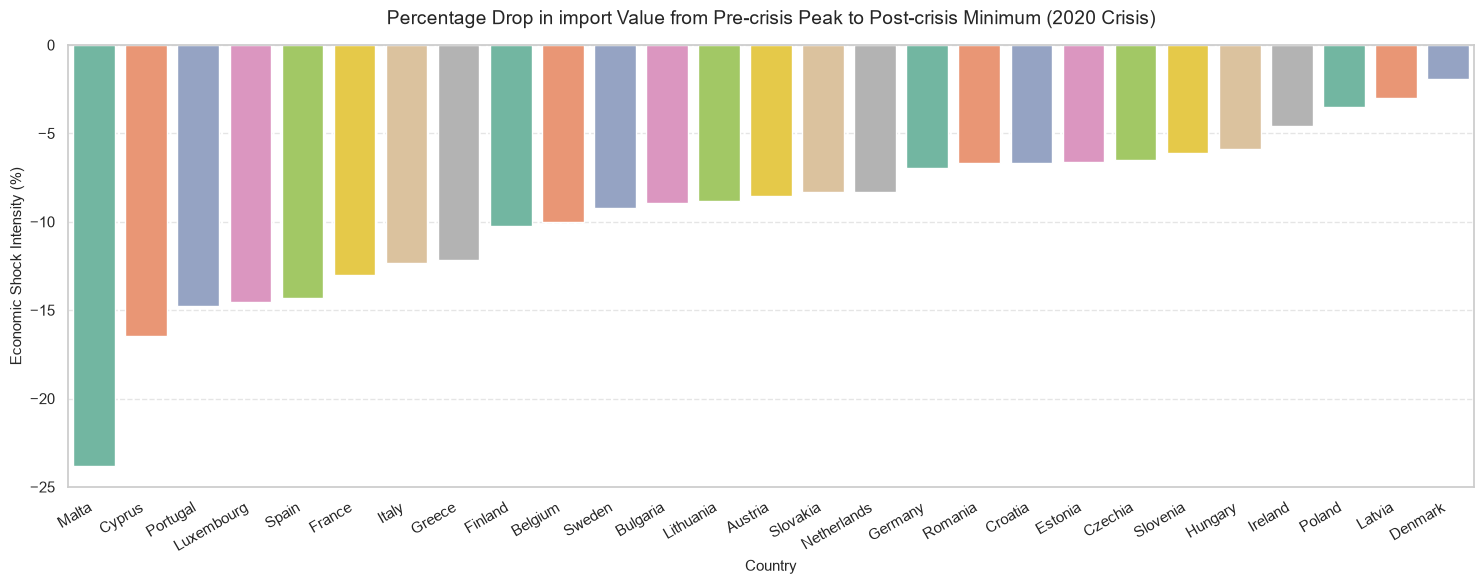

In [ ]:
plot_economic_shock(import_results_2020, trade_type="import", crisis_year="2020")
plt.savefig(Path.cwd().parent/"data/charts/precrisis_postcrisis_import_2020.png", dpi=150, bbox_inches="tight")
plt.show()

Based on the import data, the impact on imports during the 2020 crisis was more significant than the impact on exports. Unlike the export trends, there were no positive values recorded across any country. Furthermore, the average import shock (-9.06%) was deeper than the export shock (-6.98%). However, this contraction remains much heavier than what was observed during the 2008 financial crisis.

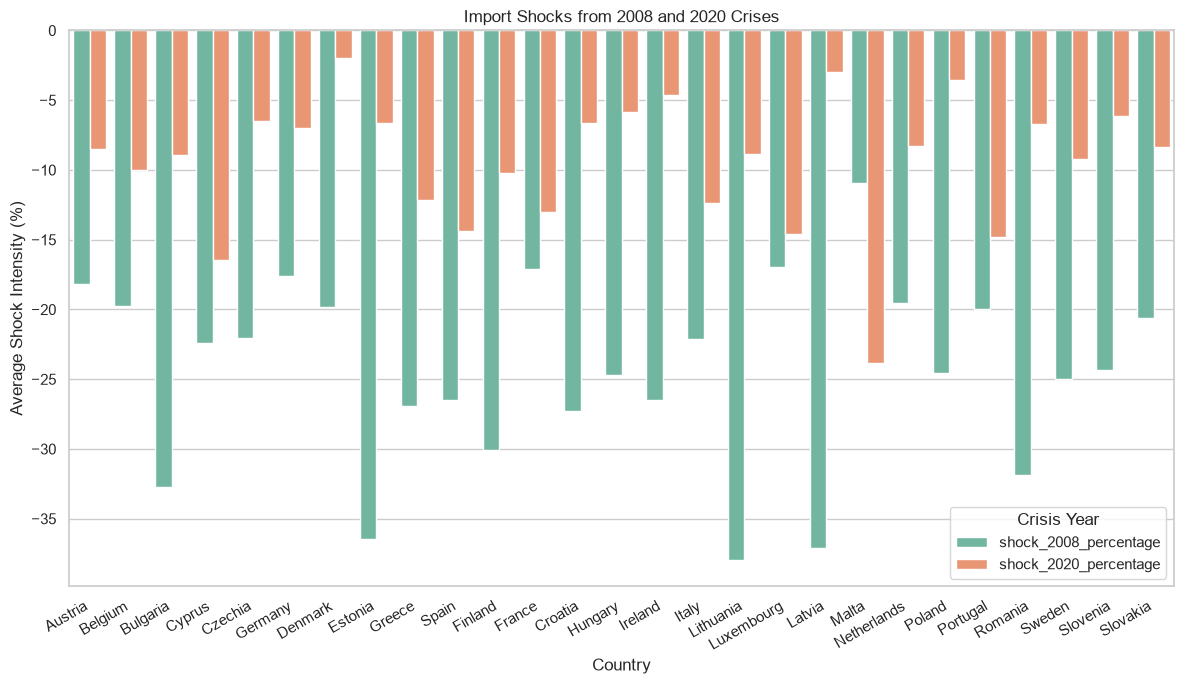

In [ ]:
plot_comparison_shock(import_results_2008, import_results_2020, trade_type="Import")
plt.savefig(Path.cwd().parent/"data/charts/comparison_import_2008_2020.png", dpi=150, bbox_inches="tight")
plt.show()

### Unemployment rate analysis for 2020 crisis.

Now I will include the unemployment rate in the analysis to observe how it was influenced by the 2020 crisis. <br>
First of all, I will generate a dataframe via SQL for the unemployment rate by country and year (including country_code, country, and rate).

In [ ]:
unemployment_series= pd.read_sql("""
        SELECT country_code, country, year, unemployment_rate
        FROM unemployment_ue
        ORDER BY country_code, year""", 
        conn)

In [ ]:
unemployment_series

,country_code,country,year,unemployment_rate
0,AT,Austria,2016,6.5
1,AT,Austria,2017,5.9
2,AT,Austria,2018,5.2
3,AT,Austria,2019,4.8
4,AT,Austria,2020,6.0
...,...,...,...,...
265,SK,Slovakia,2021,6.8
266,SK,Slovakia,2022,6.1
267,SK,Slovakia,2023,5.8
268,SK,Slovakia,2024,5.3


Testing individual steps on a single country before scaling to the entire dataframe

In [ ]:
austria_unemp = unemployment_series[unemployment_series['country_code'] == 'AT']
min_pre_crisis = austria_unemp[austria_unemp['year'].isin([2017, 2018, 2019])]['unemployment_rate'].min()

In [ ]:
min_pre_crisis

np.float64(4.8)

In [ ]:
max_post_crisis = austria_unemp[austria_unemp['year'].isin([2020, 2021,2022])]['unemployment_rate'].max()

In [ ]:
max_post_crisis

np.float64(6.2)

In [ ]:
shock_unemp = max_post_crisis - min_pre_crisis

In [ ]:
shock_unemp.round(2)

np.float64(1.4)

Creating a function to analyze pre- and post-crisis unemployment rates by country.

In [ ]:
def analyze_unemployment_shock(country_code, years_pre, years_post):
    country_data = unemployment_series[unemployment_series['country_code'] == country_code]
    
    min_pre = country_data[country_data['year'].isin(years_pre)]['unemployment_rate'].min()
    max_post = country_data[country_data['year'].isin(years_post)]['unemployment_rate'].max()
    
    shock_points = round(max_post - min_pre, 2)
    
    country_name = country_data['country'].iloc[0]
    
    return pd.DataFrame({
        "country_code": [country_code],
        "country": [country_name],
        "min_unemployment_pre": [min_pre],
        "max_unemployment_post": [max_post],
        "shock_points": [shock_points]
    })

In [ ]:
years_pre_2020 = [2017, 2018, 2019]
years_post_2020 = [2020, 2021,2022]
results_unemployment = pd.concat([analyze_unemployment_shock(code, years_pre_2020, years_post_2020) 
                                  for code in unemployment_series['country_code'].unique()], ignore_index=True)

In [ ]:
results_unemployment

,country_code,country,min_unemployment_pre,max_unemployment_post,shock_points
0,AT,Austria,4.8,6.2,1.4
1,BE,Belgium,5.5,6.3,0.8
2,BG,Bulgaria,5.2,6.1,0.9
3,CY,Cyprus,7.2,7.6,0.4
4,CZ,Czechia,2.0,2.8,0.8
5,DE,Germany,2.9,3.6,0.7
6,DK,Denmark,5.0,5.6,0.6
7,EE,Estonia,4.5,6.9,2.4
8,EL,Greece,17.9,17.6,-0.3
9,ES,Spain,14.1,15.5,1.4


In [ ]:
results_unemployment[results_unemployment['shock_points'] == results_unemployment['shock_points'].max()]

,country_code,country,min_unemployment_pre,max_unemployment_post,shock_points
7,EE,Estonia,4.5,6.9,2.4
24,SE,Sweden,6.5,8.9,2.4


In [ ]:
results_unemployment[results_unemployment['shock_points'] == results_unemployment['shock_points'].min()]

,country_code,country,min_unemployment_pre,max_unemployment_post,shock_points
11,FR,France,8.4,8.0,-0.4
15,IT,Italy,9.9,9.5,-0.4


In [ ]:
# In this case, I am using the standard mean because the values do not have significant upper or lower extremes.
results_unemployment['shock_points'].mean().round(2)

np.float64(0.92)

In [ ]:
# For robustness, I am also using the trimmed mean
trim_mean(results_unemployment['shock_points'], proportiontocut=0.05).round(2)

np.float64(0.91)

Regarding the unemployment rate, it increased following the 2020 crisis. The countries that experienced the largest increases were Estonia and Sweden, both seeing their unemployment rates rise by 2.4 points. However, there were some bucked trends, such as in Italy and France, where the unemployment rate actually dropped by 0.4 points.In general, while the unemployment rate went up, no country saw an increase exceeding 2.4 points, keeping the overall European average increase at 0.92 percentage points. <br>
Let's look more specifically at the cases of France and Italy, examining how unemployment evolved in the years leading up to the crisis.

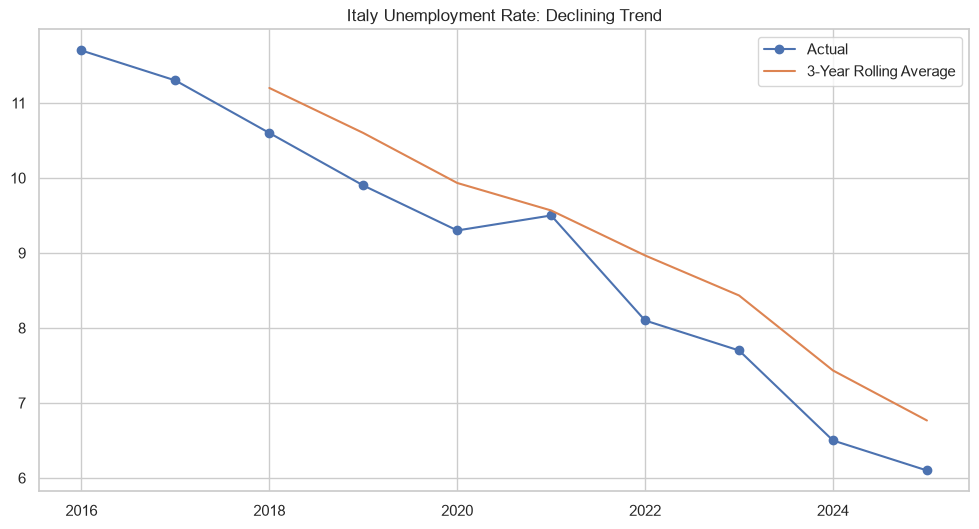

In [ ]:
Italy = unemployment_series[unemployment_series['country'] == 'Italy'].copy()
plt.figure(figsize=(12, 6))
plt.plot(Italy['year'], Italy['unemployment_rate'], label='Actual', marker='o')
plt.plot(Italy['year'], Italy['unemployment_rate'].rolling(window=3).mean(), label='3-Year Rolling Average')
plt.title('Italy Unemployment Rate: Declining Trend')
plt.legend()
plt.savefig(Path.cwd().parent/"data/charts/italy_unemployment.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
unemployment_series[(unemployment_series['country'] == 'Italy') & (unemployment_series['year'].isin([2019, 2020, 2021]))]

,country_code,country,year,unemployment_rate
153,IT,Italy,2019,9.9
154,IT,Italy,2020,9.3
155,IT,Italy,2021,9.5


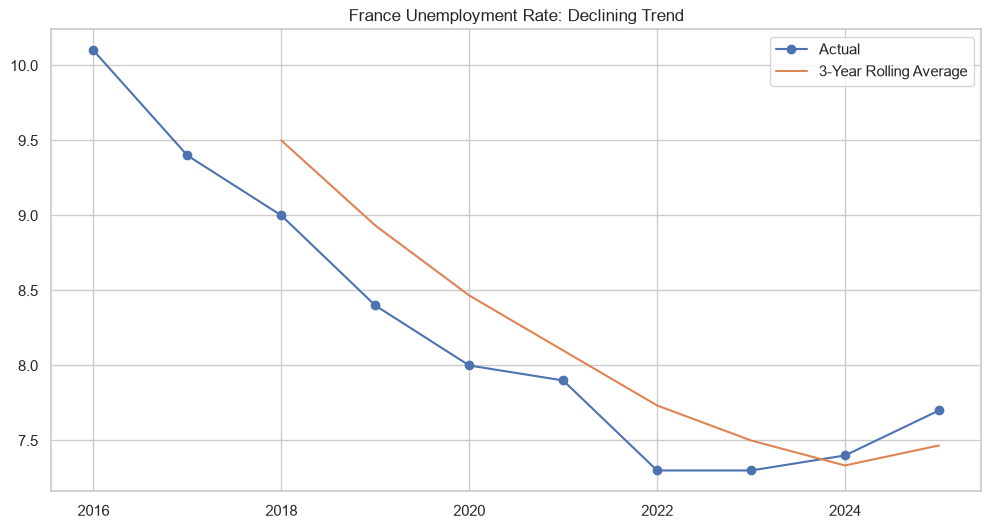

In [ ]:
France = unemployment_series[unemployment_series['country'] == 'France'].copy()
plt.figure(figsize=(12, 6))
plt.plot(France['year'], France['unemployment_rate'], label='Actual', marker='o')
plt.plot(France['year'], France['unemployment_rate'].rolling(window=3).mean(), label='3-Year Rolling Average')
plt.title('France Unemployment Rate: Declining Trend')
plt.legend()
plt.savefig(Path.cwd().parent/"data/charts/france_unemployment.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
unemployment_series[(unemployment_series['country'] == 'France') & (unemployment_series['year'].isin([2019, 2020, 2021]))]

,country_code,country,year,unemployment_rate
113,FR,France,2019,8.4
114,FR,France,2020,8.0
115,FR,France,2021,7.9


COVID-19 caused a real increase in unemployment in Italy as well (from 9.3% in 2020 to 9.5% in 2021); however, this peak remains below the unemployment levels of previous years, which were part of a long-term downward trend that began after the debt crisis. Consequently, the peak-to-trough method—by comparing the pre-crisis minimum with the crisis maximum—registers a negative shock (-0.4). This does not reflect a lack of COVID-19 impact, but rather the fact that the pandemic effect was weaker than the ongoing improvement trend. By reducing the time series to just two data points, the method fails to distinguish the crisis impact from the underlying dynamics. <br>
France's unemployment had been on a continuous downward trend before COVID (8.4% in 2019), and it kept declining through the pandemic (8.0% in 2020, 7.9% in 2021), only more slowly. Unlike Italy, France saw no outright rise in unemployment, but the pandemic still slowed the pace of improvement.

In [ ]:
#now i will merge the two dataframes to analyze the correlation between export shock and unemployment shock
export_shock_2020_complete = pd.merge(export_results_2020, results_unemployment, left_on= ["country_code", "country"], right_on= ["country_code", "country"])

In [ ]:
export_shock_2020_complete[["country", "shock_percentage", "shock_points"]]

,country,shock_percentage,shock_points
0,Austria,-7.08,1.4
1,Belgium,-7.47,0.8
2,Bulgaria,-6.12,0.9
3,Cyprus,-36.57,0.4
4,Czechia,-5.79,0.8
5,Germany,-9.11,0.7
6,Denmark,-4.24,0.6
7,Estonia,-1.03,2.4
8,Greece,-9.05,-0.3
9,Spain,-9.66,1.4


In [ ]:
export_shock_2020_complete["shock_percentage"].corr(export_shock_2020_complete["shock_points"])

np.float64(0.3198740766094203)

In [ ]:
export_shock_2020_complete["shock_percentage"].corr(export_shock_2020_complete["shock_points"], method="spearman")

np.float64(0.2942451024744173)

There is a weak positive correlation between the decline in exports during the 2020 crisis and unemployment, both with Pearson (+0.32) and Spearman (+0.29). Moreover, the extreme cases are counterintuitive: the countries that suffered the largest export collapse (Cyprus) had the smallest rise in unemployment, while countries with a smaller export drop (Sweden, Estonia) saw a sharper increase (2.4 points). This confirms that the two shocks were largely disconnected: trade was hit by the contraction in global demand for goods, while employment was likely affected by lockdowns on domestic services. The composition of the economy explains this disconnection — economies heavily weighted toward services (such as Cyprus in tourism) could have their merchandise trade intact but employment hit, and vice versa.

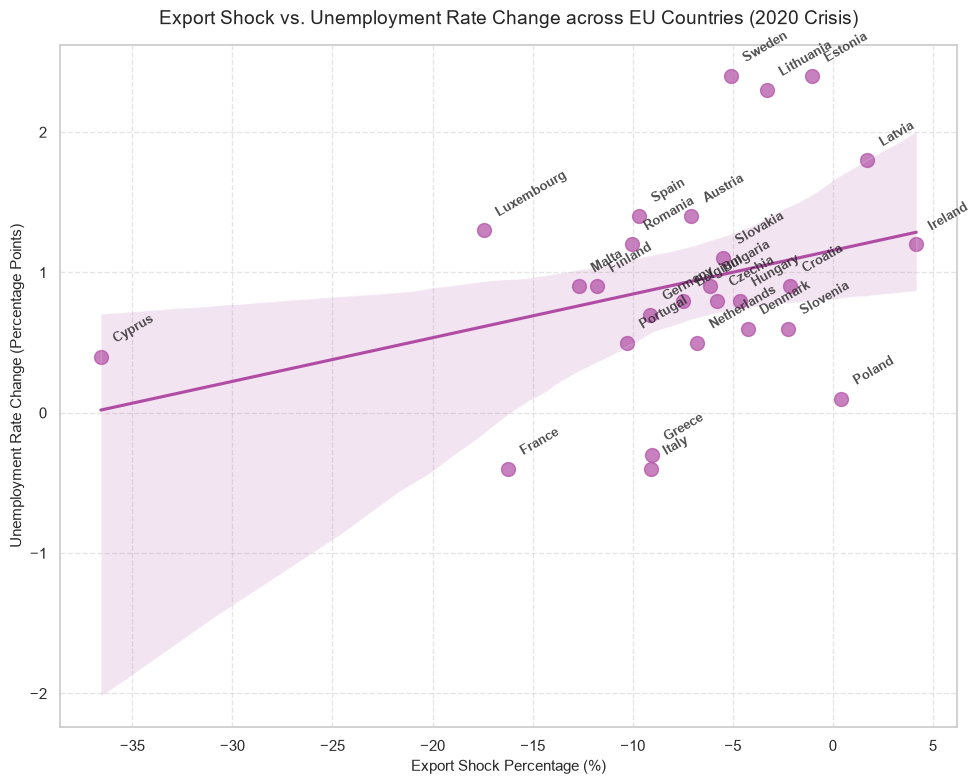

In [ ]:
df_plot = export_shock_2020_complete.reset_index()
plt.figure(figsize=(10, 8))
sns.regplot(
    data=df_plot,
    x="shock_percentage",
    y="shock_points",
    color="#b04ca4",
    scatter_kws={"s": 100, "alpha": 0.7}
)

for index, row in df_plot.iterrows():
    plt.text(
        x=row["shock_percentage"] + 0.5,      
        y=row["shock_points"] + 0.1, 
        s=row["country"],
        fontsize=9,
        weight="bold",
        alpha=0.8,
        rotation=30
    )

plt.title("Export Shock vs. Unemployment Rate Change across EU Countries (2020 Crisis)", fontsize=14, pad=15)
plt.xlabel("Export Shock Percentage (%)", fontsize=11)
plt.ylabel("Unemployment Rate Change (Percentage Points)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(Path.cwd().parent/"data/charts/unemployment_shock_2020.png", dpi=150, bbox_inches="tight")
plt.show()

For completeness, I will also analyze the relationship between the decline in imports and the unemployment rate during the 2020 crisis, although I do not expect a significant correlation.

In [ ]:
import_shock_2020_complete = pd.merge(import_results_2020, results_unemployment, left_on= ["country_code", "country"], right_on= ["country_code", "country"])

In [ ]:
import_shock_2020_complete["shock_percentage"].corr(import_shock_2020_complete["shock_points"])

np.float64(0.1893392496481569)

In [ ]:
import_shock_2020_complete["shock_percentage"].corr(import_shock_2020_complete["shock_points"], method="spearman")

np.float64(0.1383962396653867)

Pearson's correlation between imports and unemployment is even lower than that of exports, sitting at 0.19. As a robustness check, I also calculated Spearman's correlation, which yielded an even lower result of 0.14.The collapse in domestic demand, likely caused by lockdowns, did not influence unemployment as much as exports did, despite imports being more heavily hit by the 2020 crisis than exports.

### Conclusions for Comparative Crisis Analysis (2008 vs. 2020)

Comparing the impact of the two crises, it is clear that the 2008 crisis had a greater impact on both exports (average: -19.11) and imports (-24.40). The divergence indicates that the crisis hit domestic demand harder than exports. Countries with a larger export-oriented industry such as Germany, Italy, and France, along with countries with more integrated supply chains such as Czechia and Slovakia, had a faster recovery (2010-2011). Conversely, countries like Finland and Luxembourg took longer to recover their exports or did not return to pre-crisis levels (Luxembourg regarding exports), undergoing a structural shift and focusing more on domestic and financial services. A case apart is Greece, which represents the most dramatic scenario, where the profound debt crisis compounded the 2008 financial crisis, suppressing domestic consumption. Since unemployment data for the 2008 crisis was unavailable, it was not possible to analyze this aspect.

The 2020 crisis had a less devastating impact on European economies, with an export average of -6.98 and an import average of -9.06. In this case too, the divergence is explained by lower domestic demand, likely due more to the lockdowns than to the crisis itself, while remaining much lower than that of the 2008 crisis. The recovery time was much faster, and all countries returned to pre-COVID levels by 2021, or 2022 at the latest. Emblematic is the case of Cyprus and Malta; the former experienced an export collapse of -36.57% and the latter an import drop of -23.84, probably due to their geographical situation. Being islands, the impact of lockdowns on transport affected the maritime routes on which they depend. As observed, the 2020 crisis also hit the general employment level but in a contained manner, showing a slight positive correlation with the decrease in exports (Pearson correlation +0.32), whose counterintuitive sign (countries with the largest export collapse had the smallest increase in unemployment) confirms that the two shocks were largely disconnected. Even in countries where the peak-to-trough method showed a drop in unemployment (Italy and France by 0.4 points), a rolling analysis revealed a slight real increase in Italy masked by the downward trend, and a slowdown of the decline in France.

In conclusion, the 2008 financial crisis had a much stronger impact on Eurozone countries compared to the 2020 crisis, despite the latter having a significantly harsher impact on the quality of life (lockdowns). A possible interpretation, which the data suggest but do not directly prove, points to a greater preparedness of Eurozone countries for global crises, especially after the experience of 2008. Furthermore, not being an abrupt economic and financial crisis but rather one with more extended phases, it likely allowed economies to respond more precisely and implement more effective recovery strategies.